# SentraGrade — Supervised CNN Baseline + OOD Evaluation + Explainability 

In [1]:
import json, time
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.special import softmax as scipy_softmax, logsumexp
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow version: {tf.__version__}")
gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs visible: {gpus}")
if not gpus:
    print("WARNING: no GPU detected. On Mac this usually means tensorflow-metal "
          "isn't installed (or isn't working) — training will run on CPU and be slower.")

TensorFlow version: 2.19.1
GPUs visible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Get the data


In [2]:
candidates = [
    Path("~/sentragrade_data").expanduser(),
    Path.cwd(),
    Path.cwd().parent / "sentragrade_data",
]
DATA_ROOT = next(
    (p for p in candidates if (p / "folds").exists() or (p / "manifest_full.csv").exists()),
    Path("~/sentragrade_data").expanduser(),
)
FOLD_DIR = DATA_ROOT / "folds"
assert FOLD_DIR.exists(), (
    f"Fold manifests not found at {FOLD_DIR}. "
    "Expected a folder like ~/sentragrade_data created by preprocessing.py."
)
fold_summary = pd.read_csv(FOLD_DIR / "fold_summary.csv")
print(f"DATA_ROOT = {DATA_ROOT}")
print(fold_summary)

DATA_ROOT = /Users/riteeshtm/sentragrade_data
   fold     held_out_class  train_n  val_n  ood_n
0     0             Banana     3978   1037    323
1     1             Carrot     3843   1037    458
2     2              Guava     3791   1037    510
3     3  Indian_Gooseberry     3077    850   1411
4     4              Mango     3892   1054    392
5     5             Tomato     2414    680   2244


## 2. Data pipeline (tf.data)

Uses `tf.keras.applications.resnet50.preprocess_input` for normalization —
this is what the pretrained ImageNet weights expect (RGB→BGR + per-channel
mean subtraction, not the 0-1/mean-std scaling PyTorch's torchvision uses).
Images stay in the resized-256px cache from preprocessing; this pipeline
does the final crop to 224px.

In [3]:
IMG_SIZE = 224
RESIZE_SIZE = 256


def _resolve_path(class_name, filename):
    return tf.strings.join([str(DATA_ROOT), "resized", class_name, filename], separator="/")


def _load_image(path, training):
    img_bytes = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img_bytes, channels=3)
    img = tf.cast(img, tf.float32)  # keep 0-255 range; preprocess_input expects that
    img = tf.image.resize(img, [RESIZE_SIZE, RESIZE_SIZE])
    if training:
        img = tf.image.random_crop(img, [IMG_SIZE, IMG_SIZE, 3])
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, 0.15)
        img = tf.image.random_contrast(img, 0.85, 1.15)
        img = tf.image.random_saturation(img, 0.9, 1.1)
        img = tf.clip_by_value(img, 0.0, 255.0)
    else:
        offset = (RESIZE_SIZE - IMG_SIZE) // 2
        img = tf.image.crop_to_bounding_box(img, offset, offset, IMG_SIZE, IMG_SIZE)
    return img


def make_dataset(csv_path, label_map, training, batch_size=32, shuffle=False):
    df = pd.read_csv(csv_path)
    paths = [str(DATA_ROOT / "resized" / c / f) for c, f in zip(df["class_name"], df["filename"])]
    labels = df["class_name"].map(label_map).fillna(-1).astype("int32").values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=42)

    def _map(path, label):
        img = _load_image(path, training)
        img = keras.applications.resnet50.preprocess_input(img)
        return img, label

    ds = ds.map(_map, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds, df, paths, labels


def load_raw_for_display(path):
    """Same crop as eval, but WITHOUT preprocess_input — for plotting only."""
    img = _load_image(tf.constant(path), training=False)
    return tf.clip_by_value(img, 0, 255).numpy().astype("uint8")

## 3. Model — ResNet50, partial fine-tune, three views of the same graph

In [4]:
LAST_CONV_LAYER = "conv5_block3_out"
# Freezing boundary: mirrors the PyTorch version's freeze_until="layer2"
# (freeze stem + layer1 + layer2, fine-tune layer3 + layer4 + head).
# Keras ResNet50 block-name equivalents: conv1/pool1 (stem) -> conv2_block*
# (layer1) -> conv3_block* (layer2) -> conv4_block* (layer3) -> conv5_block*
# (layer4).
FROZEN_PREFIXES = ("conv1", "pool1", "conv2_block", "conv3_block")


def build_models(num_classes):
    """Returns (train_model, infer_model, grad_model) sharing one set of
    weights: train_model (logits only) is what you call .fit() on;
    infer_model (logits + pooled features) is for scoring/prototypes;
    grad_model (last conv activations + logits) is for Grad-CAM."""
    inputs = keras.Input(shape=(224, 224, 3))
    base = keras.applications.ResNet50(weights="imagenet", include_top=False, input_tensor=inputs)

    for layer in base.layers:
        layer.trainable = not layer.name.startswith(FROZEN_PREFIXES)

    conv_out = base.get_layer(LAST_CONV_LAYER).output
    pooled = keras.layers.GlobalAveragePooling2D(name="pooled_features")(conv_out)
    logits = keras.layers.Dense(num_classes, name="logits")(pooled)

    train_model = keras.Model(inputs, logits)
    infer_model = keras.Model(inputs, [logits, pooled])
    grad_model = keras.Model(inputs, [conv_out, logits])
    return train_model, infer_model, grad_model

## 4. Train one fold

In [5]:
def train_one_fold(fold_idx, epochs=25, batch_size=32, patience=6):
    print(f"\n{'='*60}\nFold {fold_idx}\n{'='*60}")

    with open(FOLD_DIR / f"fold{fold_idx}_label_map.json") as f:
        label_map = json.load(f)
    num_classes = len(label_map)

    train_ds, train_df, _, train_labels = make_dataset(
        FOLD_DIR / f"fold{fold_idx}_train.csv", label_map, training=True, batch_size=batch_size, shuffle=True
    )
    val_ds, val_df, val_paths, val_labels = make_dataset(
        FOLD_DIR / f"fold{fold_idx}_val.csv", label_map, training=False, batch_size=batch_size
    )
    ood_ds, ood_df, ood_paths, ood_labels = make_dataset(
        FOLD_DIR / f"fold{fold_idx}_ood.csv", label_map, training=False, batch_size=batch_size
    )

    class_weights = compute_class_weight("balanced", classes=np.arange(num_classes), y=train_labels)
    class_weight_dict = {i: w for i, w in enumerate(class_weights)}

    train_model, infer_model, grad_model = build_models(num_classes)
    train_model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-4),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"],
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=patience, mode="max", restore_best_weights=True
    )
    t0 = time.time()
    history = train_model.fit(
        train_ds, validation_data=val_ds, epochs=epochs, shuffle=False,
        class_weight=class_weight_dict, callbacks=[early_stop], verbose=2,
    )  # shuffle=False: already shuffled inside make_dataset via ds.shuffle()
    print(f"Trained in {time.time() - t0:.1f}s")
    best_val_acc = max(history.history["val_accuracy"])

    # infer_model shares layers with train_model (same graph, built together
    # in build_models), so it already has the best (restored) weights.
    val_logits, val_features = infer_model.predict(val_ds, verbose=0)
    ood_logits, ood_features = infer_model.predict(ood_ds, verbose=0)

    ckpt_dir = DATA_ROOT / "checkpoints" / "supervised_cnn_tf" / f"fold{fold_idx}"
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    train_model.save_weights(ckpt_dir / "model.weights.h5")
    np.savez(
        ckpt_dir / "arrays.npz",
        val_logits=val_logits, val_features=val_features, val_labels=val_labels,
        ood_logits=ood_logits, ood_features=ood_features, ood_labels=ood_labels,
    )
    with open(ckpt_dir / "meta.json", "w") as f:
        json.dump(
            {
                "label_map": label_map, "best_val_acc": float(best_val_acc),
                "val_paths": val_paths, "ood_paths": ood_paths,
            },
            f,
        )
    print(f"Saved checkpoint -> {ckpt_dir}")
    return best_val_acc

## 5. Run all 6 folds

Expensive part. Re-running this cell skips folds that already have a saved
checkpoint directory.

In [6]:
CKPT_ROOT = DATA_ROOT / "checkpoints" / "supervised_cnn_tf"
results = []

for fold_idx in fold_summary["fold"]:
    ckpt_dir = CKPT_ROOT / f"fold{fold_idx}"
    if (ckpt_dir / "meta.json").exists():
        print(f"Fold {fold_idx} already done, skipping (delete {ckpt_dir} to redo).")
        with open(ckpt_dir / "meta.json") as f:
            val_acc = json.load(f)["best_val_acc"]
    else:
        val_acc = train_one_fold(fold_idx)
    held_out = fold_summary.loc[fold_summary.fold == fold_idx, "held_out_class"].item()
    results.append({"fold": fold_idx, "held_out_class": held_out, "best_val_acc": val_acc})

results_df = pd.DataFrame(results)
print("\n=== Supervised CNN baseline (TF) — per-fold in-distribution val accuracy ===")
print(results_df)
results_df.to_csv(CKPT_ROOT / "summary.csv", index=False)


Fold 0


2026-09-05 00:20:20.198294: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-09-05 00:20:20.198326: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-09-05 00:20:20.198329: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1788547820.198361 4044025 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1788547820.198397 4044025 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 20s 0us/step
Epoch 1/25


2026-09-05 00:20:44.599761: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


125/125 - 78s - 628ms/step - accuracy: 0.9857 - loss: 0.0471 - val_accuracy: 0.9942 - val_loss: 0.0167
Epoch 2/25
125/125 - 60s - 478ms/step - accuracy: 1.0000 - loss: 5.6200e-04 - val_accuracy: 1.0000 - val_loss: 3.6301e-06
Epoch 3/25
125/125 - 59s - 469ms/step - accuracy: 1.0000 - loss: 2.0875e-04 - val_accuracy: 1.0000 - val_loss: 1.0673e-05
Epoch 4/25
125/125 - 59s - 475ms/step - accuracy: 1.0000 - loss: 9.8424e-05 - val_accuracy: 1.0000 - val_loss: 9.9671e-06
Epoch 5/25
125/125 - 59s - 474ms/step - accuracy: 0.9987 - loss: 0.0046 - val_accuracy: 0.9904 - val_loss: 0.0194
Epoch 6/25
125/125 - 58s - 465ms/step - accuracy: 1.0000 - loss: 9.1773e-04 - val_accuracy: 1.0000 - val_loss: 8.3575e-06
Epoch 7/25
125/125 - 60s - 477ms/step - accuracy: 0.9997 - loss: 2.6353e-04 - val_accuracy: 1.0000 - val_loss: 1.4786e-04
Epoch 8/25
125/125 - 57s - 460ms/step - accuracy: 1.0000 - loss: 7.4516e-05 - val_accuracy: 1.0000 - val_loss: 5.4534e-07
Trained in 491.0s
Saved checkpoint -> /Users/ritees

## 6. OOD scoring — energy, MSP, prototype distance

Same three scores as the PyTorch version, same orientation (**higher =
more OOD-like**), computed here with numpy/scipy instead of torch.

In [7]:
def load_fold_artifacts(fold_idx):
    ckpt_dir = CKPT_ROOT / f"fold{fold_idx}"
    with open(ckpt_dir / "meta.json") as f:
        meta = json.load(f)
    arrays = np.load(ckpt_dir / "arrays.npz")
    label_map = meta["label_map"]
    num_classes = len(label_map)

    train_model, infer_model, grad_model = build_models(num_classes)
    train_model.load_weights(ckpt_dir / "model.weights.h5")

    return {
        "infer_model": infer_model, "grad_model": grad_model,
        "label_map": label_map, "inv_label_map": {v: k for k, v in label_map.items()},
        "meta": meta, "arrays": arrays,
    }


def compute_class_prototypes(fc, fold_idx):
    """Mean feature vector per known class, from that fold's training set
    (no augmentation — uses the eval-style crop for stability)."""
    train_ds, _, _, train_labels = make_dataset(
        FOLD_DIR / f"fold{fold_idx}_train.csv", fc["label_map"], training=False, batch_size=32
    )
    _, train_features = fc["infer_model"].predict(train_ds, verbose=0)
    num_classes = len(fc["label_map"])
    prototypes = np.stack([train_features[train_labels == c].mean(axis=0) for c in range(num_classes)])
    return prototypes


def compute_ood_scores(logits, features, prototypes):
    probs = scipy_softmax(logits, axis=1)
    msp_score = -probs.max(axis=1)

    energy_score = -logsumexp(logits, axis=1)

    dists = cdist(features, prototypes)
    proto_score = dists.min(axis=1)

    return {"msp": msp_score, "energy": energy_score, "proto": proto_score}


fold_cache = {}
for fold_idx in fold_summary["fold"]:
    print(f"Scoring fold {fold_idx}...")
    fc = load_fold_artifacts(fold_idx)
    prototypes = compute_class_prototypes(fc, fold_idx)

    val_scores = compute_ood_scores(fc["arrays"]["val_logits"], fc["arrays"]["val_features"], prototypes)
    ood_scores = compute_ood_scores(fc["arrays"]["ood_logits"], fc["arrays"]["ood_features"], prototypes)

    fc["prototypes"] = prototypes
    fc["val_scores"] = val_scores
    fc["ood_scores"] = ood_scores
    fold_cache[fold_idx] = fc
print("Done scoring all folds.")

Scoring fold 0...
Scoring fold 1...
Scoring fold 2...
Scoring fold 3...
Scoring fold 4...
Scoring fold 5...
Done scoring all folds.


## 7. Evaluation — AUROC and FPR@95

Identical metric definitions to the PyTorch version — this part is
framework-agnostic (pure numpy/sklearn).

In [8]:
def fpr_at_tpr(labels, scores, tpr_target=0.95):
    fpr, tpr, _ = roc_curve(labels, scores)
    idx = np.searchsorted(tpr, tpr_target)
    idx = min(idx, len(fpr) - 1)
    return fpr[idx]


eval_rows = []
for fold_idx, fc in fold_cache.items():
    held_out_class = fold_summary.loc[fold_summary.fold == fold_idx, "held_out_class"].item()
    n_val = len(fc["arrays"]["val_labels"])
    n_ood = len(fc["arrays"]["ood_labels"])
    labels = np.concatenate([np.zeros(n_val), np.ones(n_ood)])
    for method in ["msp", "energy", "proto"]:
        scores = np.concatenate([fc["val_scores"][method], fc["ood_scores"][method]])
        auroc = roc_auc_score(labels, scores)
        fpr95 = fpr_at_tpr(labels, scores)
        eval_rows.append({
            "fold": fold_idx, "held_out_class": held_out_class, "method": method,
            "AUROC": auroc, "FPR@95": fpr95, "n_val": n_val, "n_ood": n_ood,
        })

eval_df = pd.DataFrame(eval_rows)
print("=== Per-fold results ===")
print(eval_df.to_string(index=False))

summary = eval_df.groupby("method")[["AUROC", "FPR@95"]].agg(["mean", "std"])
print("\n=== Aggregated across all 6 folds (mean \u00b1 std) ===")
print(summary)

eval_df.to_csv(CKPT_ROOT / "ood_eval_per_fold.csv", index=False)
summary.to_csv(CKPT_ROOT / "ood_eval_summary.csv")
print(f"\nSaved -> {CKPT_ROOT / 'ood_eval_per_fold.csv'} and ood_eval_summary.csv")

=== Per-fold results ===
 fold    held_out_class method    AUROC   FPR@95  n_val  n_ood
    0            Banana    msp 1.000000 0.000000   1037    323
    0            Banana energy 0.999913 0.000000   1037    323
    0            Banana  proto 0.970333 0.060752   1037    323
    1            Carrot    msp 0.994471 0.027001   1037    458
    1            Carrot energy 0.996366 0.018322   1037    458
    1            Carrot  proto 0.985548 0.026037   1037    458
    2             Guava    msp 0.999272 0.003857   1037    510
    2             Guava energy 0.998884 0.006750   1037    510
    2             Guava  proto 0.912846 0.103182   1037    510
    3 Indian_Gooseberry    msp 0.999983 0.000000    850   1411
    3 Indian_Gooseberry energy 0.999984 0.000000    850   1411
    3 Indian_Gooseberry  proto 0.964087 0.090588    850   1411
    4             Mango    msp 0.999959 0.000000   1054    392
    4             Mango energy 0.999935 0.000000   1054    392
    4             Mango  proto

## 8. Grad-CAM

Same idea as the PyTorch hook-based version, expressed with `tf.GradientTape`
watching the last conv block's output (`conv5_block3_out`).

In [9]:
def gradcam_heatmap(grad_model, img_batch, class_indices):
    """img_batch: [B,224,224,3] already preprocess_input'd. class_indices:
    [B] int array of which class's score to explain. Returns [B,224,224] in
    [0,1]."""
    img_tensor = tf.convert_to_tensor(img_batch, dtype=tf.float32)
    class_indices = tf.convert_to_tensor(class_indices, dtype=tf.int32)
    with tf.GradientTape() as tape:
        conv_out, logits = grad_model(img_tensor, training=False)
        tape.watch(conv_out)
        batch_idx = tf.range(tf.shape(logits)[0])
        gather_idx = tf.stack([batch_idx, class_indices], axis=1)
        class_scores = tf.gather_nd(logits, gather_idx)
    grads = tape.gradient(class_scores, conv_out)
    weights = tf.reduce_mean(grads, axis=(1, 2), keepdims=True)
    cam = tf.nn.relu(tf.reduce_sum(weights * conv_out, axis=-1))
    cam = tf.image.resize(cam[..., tf.newaxis], [224, 224])[..., 0]
    cam_min = tf.reduce_min(cam, axis=(1, 2), keepdims=True)
    cam_max = tf.reduce_max(cam, axis=(1, 2), keepdims=True)
    cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)
    return cam.numpy()

## 9. Input → output demo examples

Same demo as the PyTorch notebook: real images in, decision + Grad-CAM
heatmap out. Threshold is the 95th percentile of that fold's known-class
energy scores (keeps 95% of legitimate produce, flags the rest as a
false-reject budget).

Demo fold 0 (held out: Banana), method=energy, threshold=-10.7794


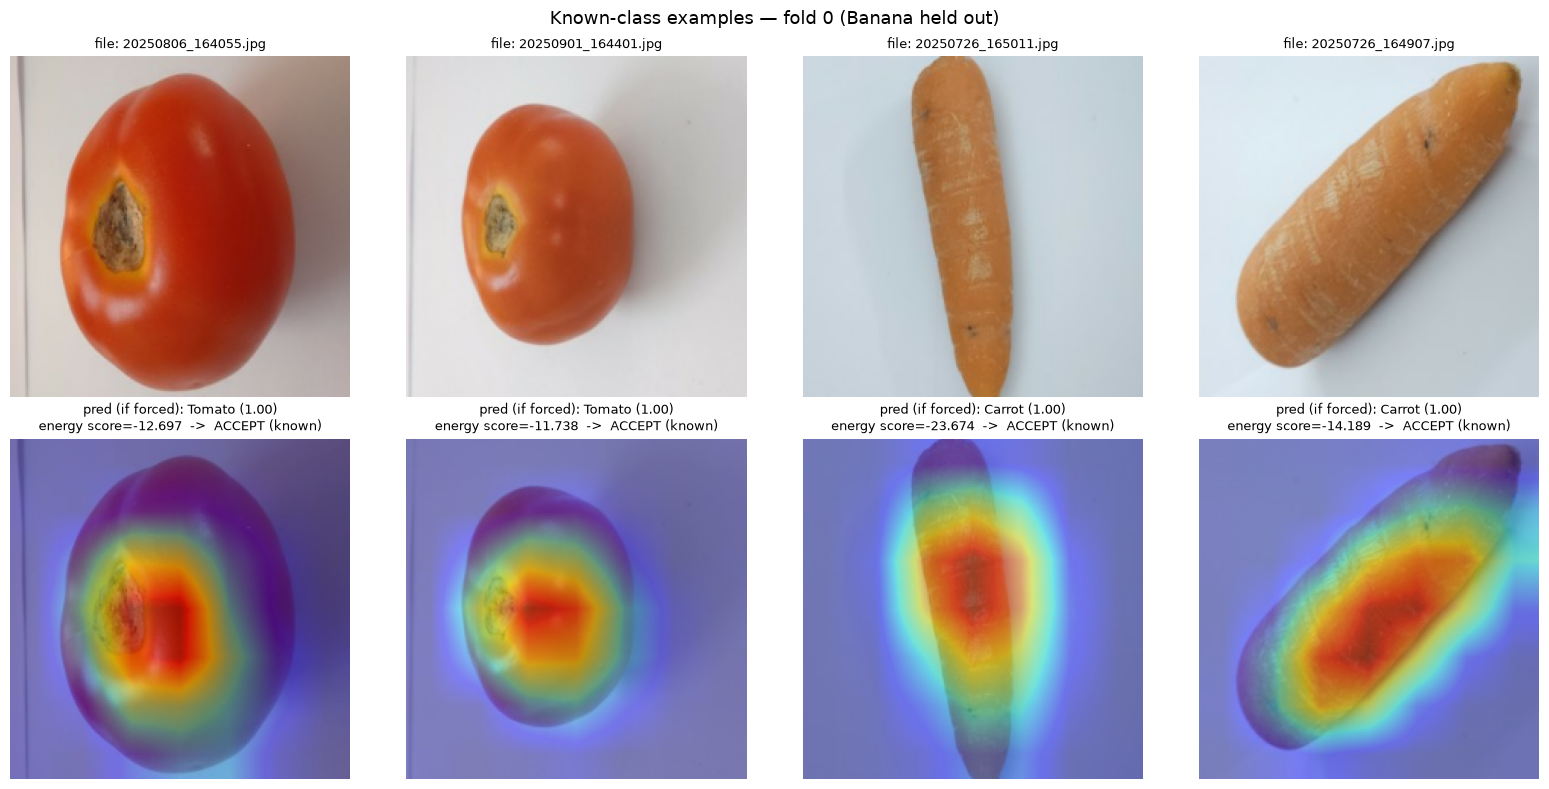

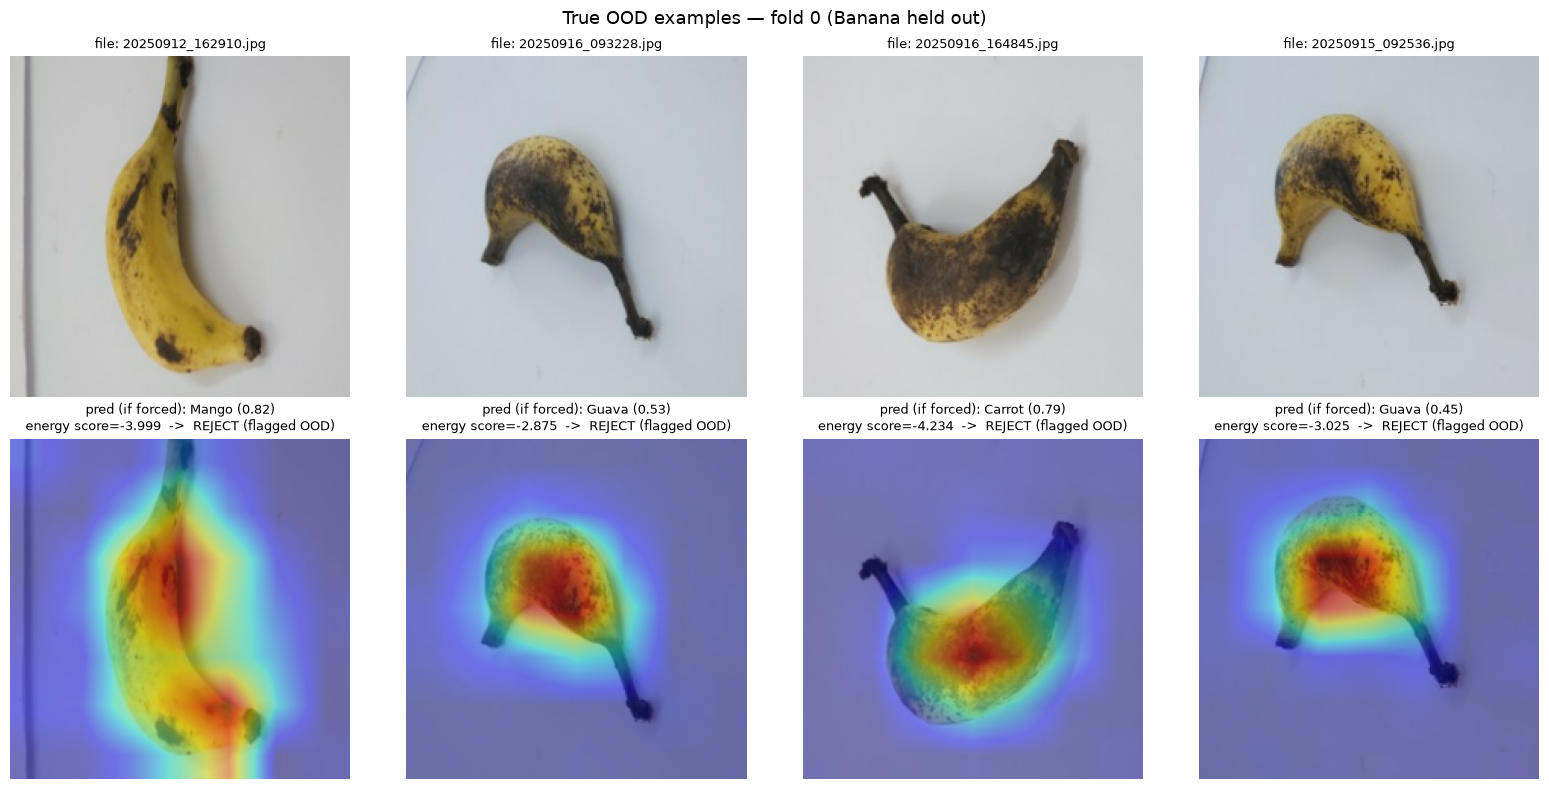


At this threshold: 323/323 true Banana images (100.0%) were correctly flagged as OOD.
The 'pred (if forced)' label on the OOD row shows what a standard closed-set
classifier would have wrongly called it, had nothing caught it.


In [10]:
DEMO_FOLD = 0
DEMO_METHOD = "energy"
N_ID_EXAMPLES = 4
N_OOD_EXAMPLES = 4

fc = fold_cache[DEMO_FOLD]
held_out_class = fold_summary.loc[fold_summary.fold == DEMO_FOLD, "held_out_class"].item()
threshold = float(np.percentile(fc["val_scores"][DEMO_METHOD], 95))
print(f"Demo fold {DEMO_FOLD} (held out: {held_out_class}), method={DEMO_METHOD}, threshold={threshold:.4f}")


def show_examples(paths, logits, scores, threshold, title):
    n = len(paths)
    fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))
    if n == 1:
        axes = axes.reshape(2, 1)

    pred_classes = logits.argmax(axis=1)
    probs = scipy_softmax(logits, axis=1)
    confidences = probs.max(axis=1)

    imgs_for_cam = []
    for path in paths:
        raw = tf.io.read_file(path)
        img = tf.image.decode_jpeg(raw, channels=3)
        img = tf.cast(img, tf.float32)
        img = tf.image.resize(img, [RESIZE_SIZE, RESIZE_SIZE])
        offset = (RESIZE_SIZE - IMG_SIZE) // 2
        img = tf.image.crop_to_bounding_box(img, offset, offset, IMG_SIZE, IMG_SIZE)
        imgs_for_cam.append(keras.applications.resnet50.preprocess_input(img).numpy())
    imgs_for_cam = np.stack(imgs_for_cam)

    cams = gradcam_heatmap(fc["grad_model"], imgs_for_cam, pred_classes)

    for i, path in enumerate(paths):
        disp_img = load_raw_for_display(path)
        pred_class = fc["inv_label_map"][int(pred_classes[i])]
        decision = "REJECT (flagged OOD)" if scores[i] > threshold else "ACCEPT (known)"

        axes[0, i].imshow(disp_img)
        axes[0, i].axis("off")
        axes[0, i].set_title(f"file: {Path(path).name}", fontsize=9)

        axes[1, i].imshow(disp_img)
        axes[1, i].imshow(cams[i], cmap="jet", alpha=0.45)
        axes[1, i].axis("off")
        axes[1, i].set_title(
            f"pred (if forced): {pred_class} ({confidences[i]:.2f})\n"
            f"{DEMO_METHOD} score={scores[i]:.3f}  ->  {decision}",
            fontsize=9,
        )
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


val_paths = fc["meta"]["val_paths"]
val_logits = fc["arrays"]["val_logits"]
val_scores_arr = fc["val_scores"][DEMO_METHOD]
id_idx = np.random.RandomState(0).choice(len(val_paths), size=min(N_ID_EXAMPLES, len(val_paths)), replace=False)
show_examples(
    [val_paths[i] for i in id_idx], val_logits[id_idx], val_scores_arr[id_idx], threshold,
    f"Known-class examples — fold {DEMO_FOLD} ({held_out_class} held out)",
)

ood_paths = fc["meta"]["ood_paths"]
ood_logits = fc["arrays"]["ood_logits"]
ood_scores_arr = fc["ood_scores"][DEMO_METHOD]
ood_idx = np.random.RandomState(0).choice(len(ood_paths), size=min(N_OOD_EXAMPLES, len(ood_paths)), replace=False)
show_examples(
    [ood_paths[i] for i in ood_idx], ood_logits[ood_idx], ood_scores_arr[ood_idx], threshold,
    f"True OOD examples — fold {DEMO_FOLD} ({held_out_class} held out)",
)

n_caught = int((ood_scores_arr > threshold).sum())
print(f"\nAt this threshold: {n_caught}/{len(ood_scores_arr)} true {held_out_class} images "
      f"({100*n_caught/len(ood_scores_arr):.1f}%) were correctly flagged as OOD.")
print("The 'pred (if forced)' label on the OOD row shows what a standard closed-set")
print("classifier would have wrongly called it, had nothing caught it.")